<a href="https://colab.research.google.com/github/BandanaSingha24/Integrated_Multiomic_Survival_Model/blob/main/03_EDA/Clinical_Gene-expression_merged_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
df_clinical=pd.read_csv("/content/processed_clinical_data.csv")
df_expression=pd.read_csv("/content/processed_gene_expression_feature_engineering.csv")
print('Clinical Data Head:\n', df_clinical.head())
print('\nExpression Data Head:\n', df_expression.head())

Clinical Data Head:
   PATIENT_ID  LYMPH_NODES_EXAMINED_POSITIVE    NPI CELLULARITY CHEMOTHERAPY  \
0    MB-0000                           10.0  6.044     Unknown           NO   
1    MB-0002                            0.0  4.020        High           NO   
2    MB-0005                            1.0  4.030        High          YES   
3    MB-0006                            3.0  4.050    Moderate          YES   
4    MB-0008                            8.0  6.080        High          YES   

   COHORT   ER_IHC HER2_SNP6 HORMONE_THERAPY INFERRED_MENOPAUSAL_STATE  ...  \
0     1.0  Positve   NEUTRAL             YES                      Post  ...   
1     1.0  Positve   NEUTRAL             YES                       Pre  ...   
2     1.0  Positve   NEUTRAL             YES                       Pre  ...   
3     1.0  Positve   NEUTRAL             YES                       Pre  ...   
4     1.0  Positve   NEUTRAL             YES                      Post  ...   

                        CANCE

In [11]:
# Step 1: Merging Clinical and Gene Expression Data ---

import pandas as pd

# Perform the merge operation on 'PATIENT_ID' from clinical and 'Entrez_Gene_Id' from expression data
merged_df = pd.merge(df_clinical, df_expression, left_on='PATIENT_ID', right_on='Entrez_Gene_Id', how='inner')

# Verify the result of the merge
print("Merged dataset shape:", merged_df.shape)
print(merged_df.head())

# Save the merged dataset for the next module
merged_df.to_csv("clinical_gene-expression_integrated_data.csv", index=False)

Merged dataset shape: (115, 20390)
  PATIENT_ID  LYMPH_NODES_EXAMINED_POSITIVE    NPI CELLULARITY CHEMOTHERAPY  \
0    MB-0050                            3.0  4.066    Moderate          YES   
1    MB-0066                            1.0  4.032        High           NO   
2    MB-0102                           16.0  5.080        High          YES   
3    MB-0117                            1.0  4.046    Moderate           NO   
4    MB-0138                            0.0  3.036    Moderate           NO   

   COHORT   ER_IHC HER2_SNP6 HORMONE_THERAPY INFERRED_MENOPAUSAL_STATE  ...  \
0     1.0  Positve   NEUTRAL             YES                       Pre  ...   
1     1.0  Positve   NEUTRAL             YES                      Post  ...   
2     1.0  Positve   NEUTRAL             YES                      Post  ...   
3     1.0  Positve   NEUTRAL             YES                      Post  ...   
4     1.0  Positve      LOSS             YES                      Post  ...   

   283104.0  31

In [17]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# step 2: Calculating p-value and Log2FC for Volcano plot

# 1: Divide the data into two groups based on Chemotherapy response
group_yes = merged_df[merged_df['CHEMOTHERAPY'] == 'YES']
group_no = merged_df[merged_df['CHEMOTHERAPY'] == 'NO']

# 2: Define gene columns (excluding clinical data columns)
# The true gene expression columns are those from df_expression, excluding the 'Entrez_Gene_Id'
# which is the patient identifier in the expression data.
gene_columns = df_expression.columns.drop('Entrez_Gene_Id').tolist()

results = []

# 3: Calculate p-value and log2FC for each gene using a loop
for gene in gene_columns:
    # Perform t-test
    # t-test निष्पादित करें
    t_stat, p_val = stats.ttest_ind(group_yes[gene], group_no[gene], nan_policy='omit')

    # Calculate log2 fold change
    # log2 fold change की गणना करें
    mean_yes = np.mean(group_yes[gene])
    mean_no = np.mean(group_no[gene])
    # If the expression data is already log-transformed, the log2 fold change is the difference of the means.
    log2fc = mean_yes - mean_no

    results.append({'gene': gene, 'log2FC': log2fc, 'pval': p_val})

# Step 4: Create a results DataFrame for plotting
df_results = pd.DataFrame(results)

print("Calculations complete. You can now proceed to Volcano Plot.")

Calculations complete. You can now proceed to Volcano Plot.


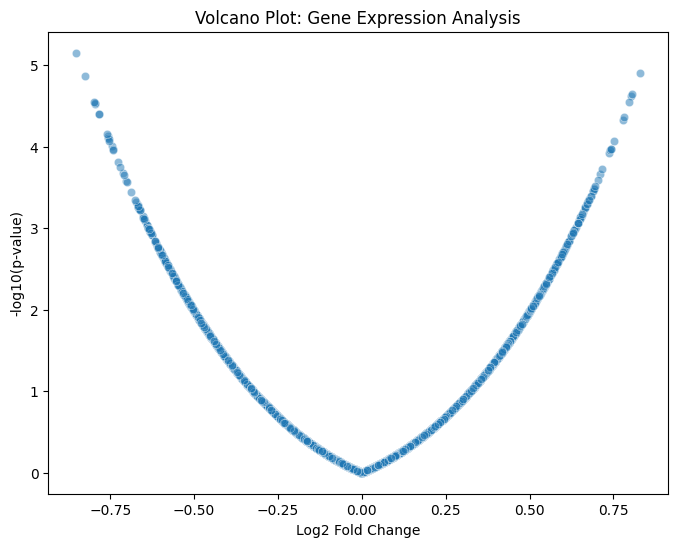

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 3: Visualize gene expression significance using a Volcano Plot
# स्टेप: वोल्केनो प्लॉट का उपयोग करके जीन एक्सप्रेशन के महत्व को दर्शाना

plt.figure(figsize=(8, 6))
# Plotting Log2 Fold Change against -log10 p-value
# Log2 Fold Change को -log10 p-value के खिलाफ प्लॉट करना
sns.scatterplot(data=df_results, x='log2FC', y=-np.log10(df_results['pval']), alpha=0.5)

plt.title("Volcano Plot: Gene Expression Analysis")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.show()

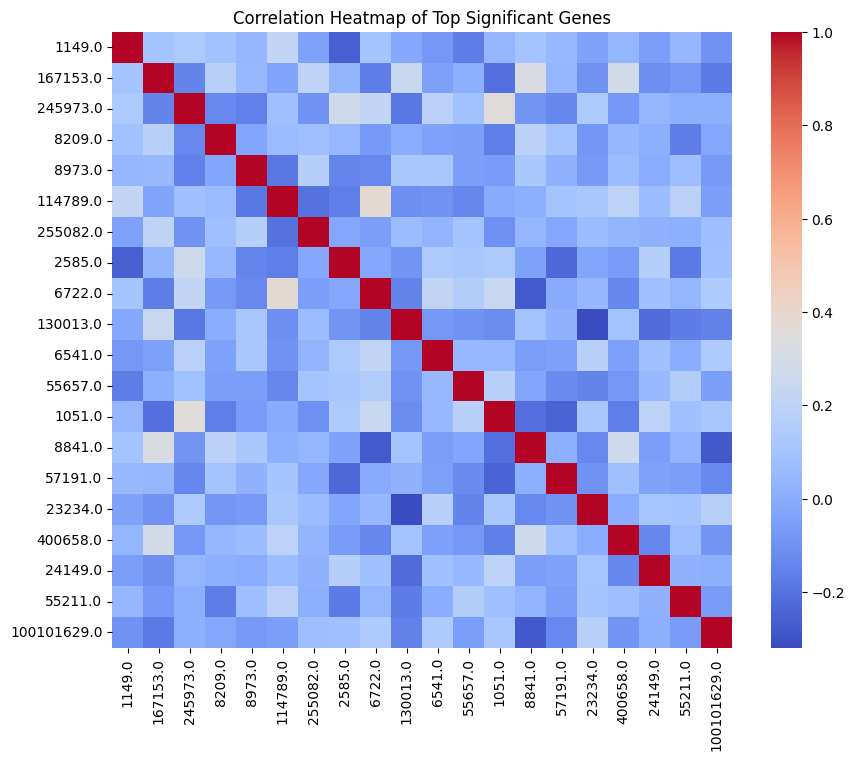

In [20]:
# Step 4: Create a Correlation Heatmap for significant genes

import seaborn as sns
import matplotlib.pyplot as plt

# Selecting only significant genes (P-value < 0.05)
significant_genes = df_results[df_results['pval'] < 0.05]['gene'].head(20)

# Creating a subset for correlation analysis
heatmap_data = merged_df[significant_genes].corr()

plt.figure(figsize=(10, 8))
# Generating the heatmap
sns.heatmap(heatmap_data, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Top Significant Genes")
plt.show()

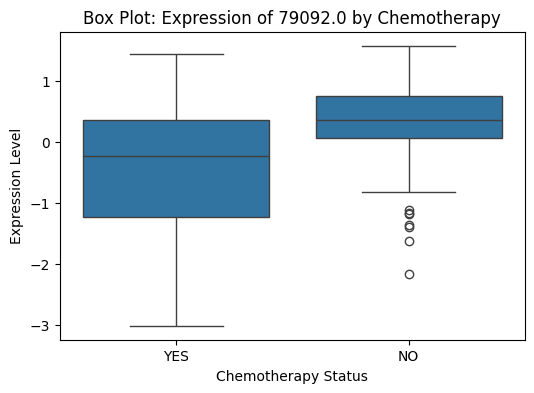

In [21]:
# Step 5: Create a Box Plot to compare top gene expression across Chemotherapy groups

import seaborn as sns
import matplotlib.pyplot as plt

# Choosing the top most significant gene from your result
top_gene = df_results.sort_values(by='pval')['gene'].iloc[0]

plt.figure(figsize=(6, 4))
# Plotting the expression distribution for the top gene
sns.boxplot(x='CHEMOTHERAPY', y=top_gene, data=merged_df)

plt.title(f"Box Plot: Expression of {top_gene} by Chemotherapy")
plt.xlabel("Chemotherapy Status")
plt.ylabel("Expression Level")
plt.show()


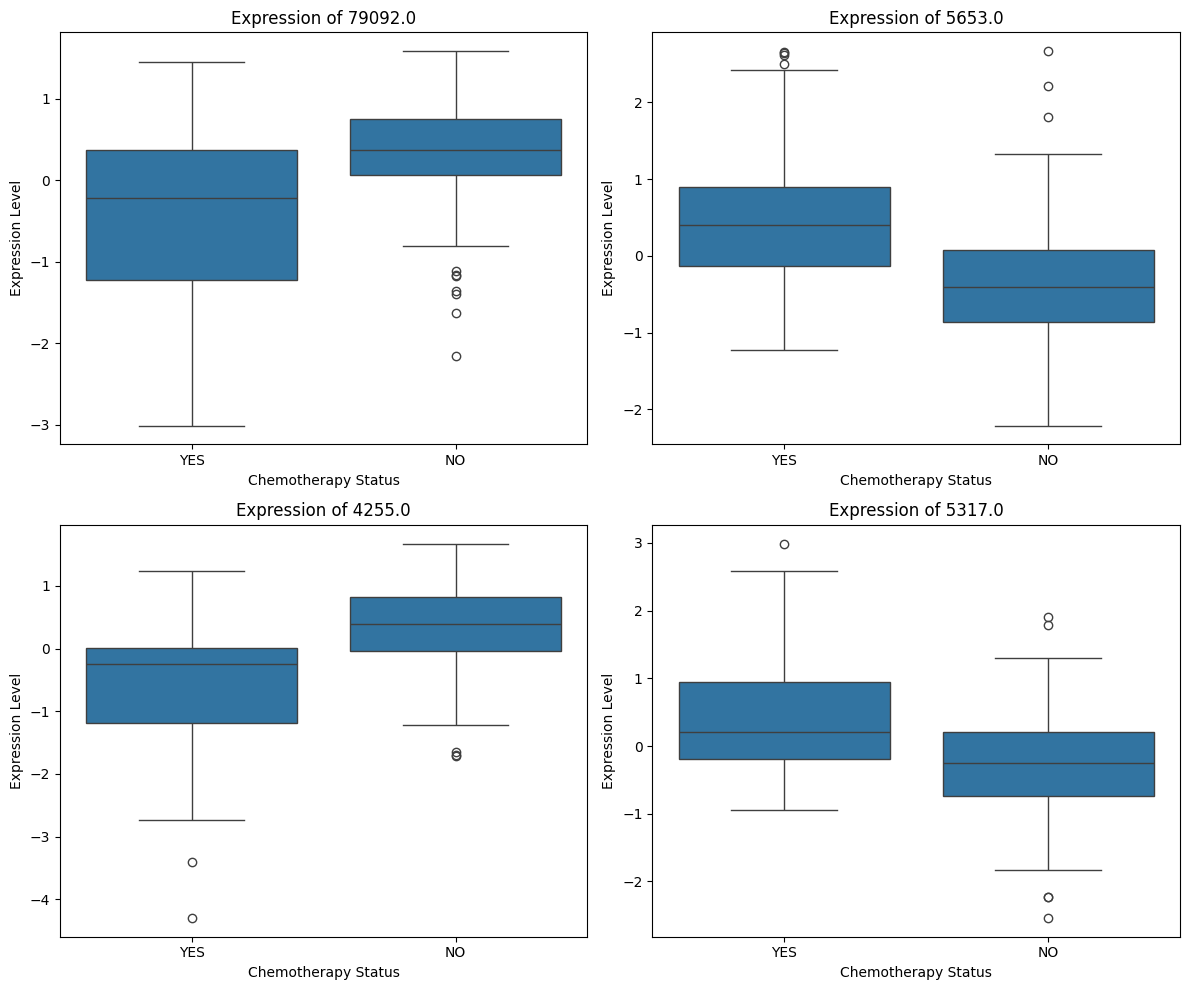

In [22]:
# Step 6: Multi Gene Box Plot for top 4 significant genes

import seaborn as sns
import matplotlib.pyplot as plt

# Get the top 4 genes based on the lowest p-value
top_4_genes = df_results.sort_values(by='pval')['gene'].head(4).tolist()

# Create a 2x2 grid for subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each gene in the grid
for i, gene in enumerate(top_4_genes):
    sns.boxplot(x='CHEMOTHERAPY', y=gene, data=merged_df, ax=axes[i])
    axes[i].set_title(f"Expression of {gene}")
    axes[i].set_xlabel("Chemotherapy Status")
    axes[i].set_ylabel("Expression Level")

plt.tight_layout()
plt.show()


In [24]:
# Step 7: Creating a Summary Table of significant genes

# Sort by p-value and get the top 10
summary_table = df_results.sort_values(by='pval').head(10)

# Display the tabl
print("Top 10 Significant Genes Summary:")
print(summary_table[['gene', 'pval', 'log2FC']])

# Save to CSV for your records
summary_table.to_csv('Top10__significant_genes_summary.csv', index=False)
print("\nSummary saved as 'Top10_significant_genes_summary.csv'")


Top 10 Significant Genes Summary:
           gene      pval    log2FC
8289    79092.0  0.000007 -0.850821
8170     5653.0  0.000013  0.829051
17566    4255.0  0.000014 -0.825666
13936    5317.0  0.000023  0.806145
6881     1381.0  0.000024  0.803688
12251    3868.0  0.000028  0.797668
11634    5164.0  0.000029 -0.797089
11439  282679.0  0.000029 -0.796369
5325     2166.0  0.000030 -0.795109
20235    5252.0  0.000040 -0.783860

Summary saved as 'Top10_significant_genes_summary.csv'
